# ANN - Regresión Caso Ecommerce

In [1]:
import pandas as pd
import numpy as np

## Lectura de Datos

In [3]:
df = pd.read_csv('Ecommerce.csv')

In [4]:
df.head(2)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


## Limpieza de Datos

In [ ]:
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

## Planteamiento del modelo

In [8]:
X = df[['Avg. Session Length','Time on App','Time on Website','Length of Membership']]
y = df['Yearly Amount Spent']

## Preprocesamiento

Haremos lo siguiente:

*   Escalamiento



### Escalamiento

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()
X_enc = scaler.fit_transform(X)

In [33]:
X_enc[:2]

array([[ 1.45635117,  0.60728003,  2.49358859,  0.55010651],
       [-1.13650215, -0.94946372,  0.20655573, -0.87092735]])

### Validacion Cruzada

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)

### Arquitectura de la red neuronal

La arquitectura es un arte. En este caso, utilizaremos capas densas (fully connected)

*  Probar con activation: relu, tanh, linear
*  Probar optimizadores: Adam, SGD, RMSProp, Adagrad
*  Probar combinaciones de capas

In [36]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import plot_model

In [37]:
model = Sequential()
model.add(Input(shape=(4,))) #capa de entrada
model.add(Dense(20, activation='linear')) #capa oculta
model.add(Dense(10, activation='linear')) #capa oculta
model.add(Dense(1, activation='linear')) #capa de salida

In [62]:
model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.01),
              metrics=[r2])

In [67]:
import tensorflow as tf
from keras import backend as K

def r2(y_true, y_pred):
    # Convert y_true to a TensorFlow tensor and ensure consistent dtype
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Ensure y_pred is 1-dimensional to match y_true
    y_pred = tf.squeeze(y_pred)

    SS_res = tf.reduce_sum(tf.square(y_true - y_pred))
    SS_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return (1 - SS_res / (SS_tot + K.epsilon()))

### Visualización del modelo

In [45]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 20)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
X_train

array([[ 0.73314361, -0.13577217, -0.21368631,  0.10170962],
       [ 1.2354693 , -0.23133443, -0.74484059, -1.4185221 ],
       [-0.43903853,  1.95032608,  0.12883727,  0.53200325],
       ...,
       [-1.25125901, -1.17352219, -2.14231308, -0.40552112],
       [-0.79996391,  2.09460507, -0.03661911,  0.22900329],
       [-0.63283097, -0.6077061 ,  0.51486516, -0.94812651]])

### Entrenamiento

In [74]:
model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.01),
              metrics=[r2])
history = model.fit(X_train, y_train, batch_size=128, epochs=50, validation_split=0.1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 157.7456 - r2: -241.9821 - val_loss: 123.4587 - val_r2: -76.7880
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 151.0520 - r2: -230.7467 - val_loss: 134.7891 - val_r2: -80.2278
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 121.0861 - r2: -245.1619 - val_loss: 135.1605 - val_r2: -82.6884
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 119.3756 - r2: -239.9330 - val_loss: 113.4551 - val_r2: -77.6331
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 114.1316 - r2: -230.2439 - val_loss: 118.1497 - val_r2: -78.0135
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 103.9966 - r2: -236.1348 - val_loss: 111.9095 - val_r2: -81.0743
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 116.3161 - r2: -245.3037 - val_loss: 111.8150 - val_r2: -80.9182
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 100.0750 - r2: -239.0885 - val_loss: 112.8370 - val_r2: -77.8292
Epoch 9/50
3/3 ━━━━━━━━

## Evaluación

In [75]:
from sklearn.metrics import r2_score

In [76]:
X_test

array([[-9.83897681e-01, -1.71624560e+00,  1.96607598e+00,
        -9.90724634e-02],
       [-2.46574536e-01,  7.69844006e-01, -2.86348060e-02,
         3.18666075e-01],
       [-1.61939847e+00, -1.96417105e+00,  9.73777849e-01,
         7.06050646e-01],
       [-6.08804145e-01,  1.41482827e+00,  1.76685641e-01,
        -5.93072235e-01],
       [-1.67775140e+00, -1.06548707e+00,  1.00448656e+00,
        -1.04782116e-01],
       [-6.27645962e-01,  1.84731059e+00,  1.30910299e+00,
         2.39920678e-01],
       [ 2.00112583e+00, -1.17348488e-01, -1.26453651e+00,
        -2.23696476e-01],
       [-3.87277761e-02, -2.93303950e-01,  5.04932716e-01,
         3.01226906e-01],
       [-6.27727297e-01, -7.51349067e-01,  6.14137070e-01,
        -7.55241570e-01],
       [-5.52717942e-02, -1.11319245e+00,  5.81847931e-01,
         2.93073815e-01],
       [-1.12613819e+00, -2.39986536e-01,  8.39273466e-02,
        -3.31225947e-01],
       [ 4.09737396e-01, -6.68406516e-01,  8.40724979e-01,
      

In [77]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [78]:
r2_score(y_test,y_pred)

0.9766954992733337

In [72]:
import tensorflow as tf
from keras import backend as K

def r2(y_true, y_pred):
    # Convert y_true to a TensorFlow tensor and ensure consistent dtype
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Ensure y_pred is 1-dimensional to match y_true
    y_pred = tf.squeeze(y_pred)

    SS_res = tf.reduce_sum(tf.square(y_true - y_pred))
    SS_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return (1 - SS_res / (SS_tot + K.epsilon()))

r2(y_test, y_pred)

<tf.Tensor: shape=(), dtype=float32, numpy=0.9770758152008057>

## Evolución del entrenamiento

In [59]:
import matplotlib.pyplot as plt
%matplotlib inline

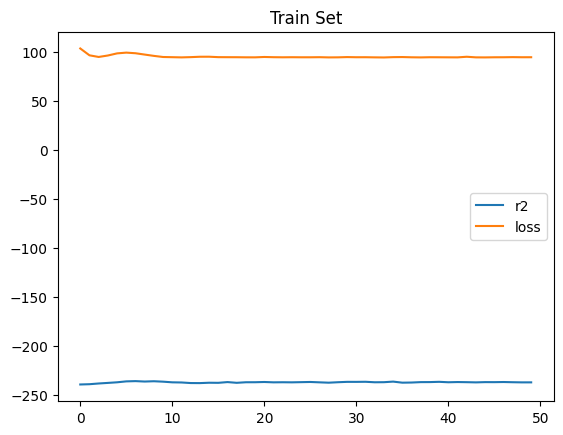

In [60]:
plt.title('Train Set')
plt.plot(history.history['r2'], label='r2')
plt.plot(history.history['loss'], label='loss')
plt.legend(loc=0)

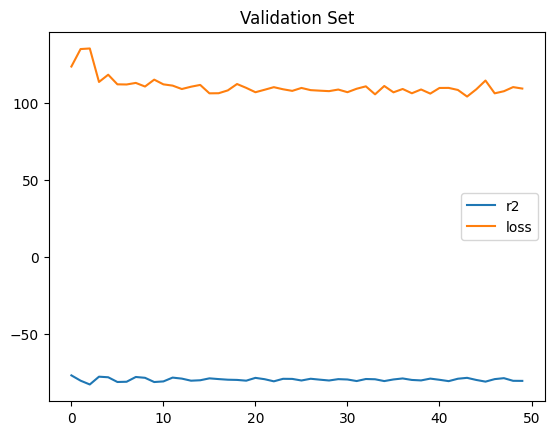

In [79]:
plt.title('Validation Set')
plt.plot(history.history['val_r2'], label='r2')
plt.plot(history.history['val_loss'], label='loss')
plt.legend(loc=0)